# Railroad Interest Labor Coverage Regression

Tests whether newspaper owners with railroad financial ties produced more anti-labor coverage.

**Unit of observation:** newspaper Ã— year  
**Outcome:** `anti_labor_intensity` = anti-labor articles / total labor articles  
**Treatment:** `railroad_interest` = 1 if any coded owner had a financial railroad tie (stockholder, board member, company owner, donation, professional services, or family connection)

**Control group:** only persons with at least one explicit 0 across the railroad interest fields and no positive values â€” "confirmed non-railroad". Persons with all-NaN coding (never coded) are dropped from the analysis.

In [1]:
import pandas as pd
import sqlite3
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

DB_PATH   = 'data/newspapers.db'
OE_PATH   = 'data/personnel_coding/owners_and_editors.csv'
CODE_PATH = 'data/personnel_coding/combined_coding.csv'

## 1. Build railroad interest indicator

In [2]:
coding = pd.read_csv(CODE_PATH)

RAILROAD_COLS = [
    'railroad_stockholder', 'railroad_board_member', 'railroad_company_owner',
    'railroad_donation', 'railroad_professional_services', 'family_connection_railroad'
]

# railroad_interest=1: any column is > 0
coding['railroad_interest'] = (coding[RAILROAD_COLS].fillna(0) > 0).any(axis=1).astype(int)

# confirmed_control=1: at least one column has an explicit 0, and none are > 0
has_explicit_zero = (coding[RAILROAD_COLS] == 0).any(axis=1)
coding['confirmed_control'] = has_explicit_zero & (coding['railroad_interest'] == 0)

# Keep only persons who are either treated or confirmed controls
person_rr = coding[coding['railroad_interest'] | coding['confirmed_control']].copy()
person_rr = person_rr[['person_id', 'name', 'railroad_interest']].dropna(subset=['person_id'])
person_rr['person_id'] = person_rr['person_id'].astype(int)

print(f"Treated (railroad_interest=1): {coding['railroad_interest'].sum()}")
print(f"Confirmed controls:            {coding['confirmed_control'].sum()}")
print(f"Dropped (all NaN / uncoded):   {len(coding) - len(person_rr)}")
print(f"\nPersons in analysis: {len(person_rr)}")
print("\nTreated:")
for _, r in person_rr[person_rr['railroad_interest'] == 1].iterrows():
    print(f"  {r['name']}")
print("\nControls:")
for _, r in person_rr[person_rr['railroad_interest'] == 0].iterrows():
    print(f"  {r['name']}")

Treated (railroad_interest=1): 21
Confirmed controls:            26
Dropped (all NaN / uncoded):   416

Persons in analysis: 47

Treated:
  Whitelaw Reid
  Edgar Snowden
  James Gordon Bennett
  Lewis Baker
  Buckley B. Paddock | Walter Malone
  John F. Morse
  John Bennett Carrington, Sr.
  J. H. Estill
  H. Smith | A. J. Steinman | E. H. Thomas
  Charles M. Stone
  Edward Scull
  C. W. Willard
  Levi G. Gould
  Wm. H. Simpson
  Alfales Young
  Ignatius Donnelly
  General John M. Hedrick | Major Augustus H. Hamilton
  John M. Hedrick
  D. R. Anthony
  Jay Gould
  Wilmer Atkinson | Howard Jenkins

Controls:
  Charles A. Dana | George Ripley | Bayard Taylor | Henry J. Raymond | Horace Greeley | Margaret Fuller
  Crosby Noyes
  Harlan P. Hall
  John C. New
  Berry R. Sulgrove
  Alfred Doten
  George Vernon
  William Osman | Douglas Hapeman
  John M. Keating | Matthew Gallaway
  William L. Norris
  A. McGregor
  Walter Murray Gibson
  Paul Fontaine | Albert L. Fontaine
  Samuel Denison Ha

## 2. Link owners â†’ newspapers (issn + active years)

In [3]:
oe = pd.read_csv(OE_PATH)

# Keep only rows with a known person and a valid issn
oe_persons = oe.dropna(subset=['person_id', 'issn']).copy()
oe_persons['person_id'] = oe_persons['person_id'].astype(int)

# Merge in railroad interest
oe_persons = oe_persons.merge(person_rr, on='person_id', how='inner')

# Expand year ranges: 'years' column is like "1871; 1873; 1876"
def parse_years(s):
    if pd.isna(s):
        return []
    return [int(y.strip()) for y in str(s).split(';') if y.strip().isdigit()]

rows = []
for _, row in oe_persons.iterrows():
    for yr in parse_years(row['years']):
        rows.append({'issn': row['issn'], 'year': yr,
                     'person_id': row['person_id'], 'railroad_interest': row['railroad_interest']})

person_paper_year = pd.DataFrame(rows)
print(f"Person-paper-year rows: {len(person_paper_year)}")
print(person_paper_year.head())

Person-paper-year rows: 669
        issn  year  person_id  railroad_interest
0  1941-0646  1890          3                  1
1  1941-0646  1869          4                  0
2  1941-0646  1871          4                  0
3  1941-0646  1873          3                  1
4  1941-0646  1876          3                  1


In [4]:
# Aggregate to newspaper-year: 1 if ANY owner in that year had railroad interest
paper_year_rr = (
    person_paper_year
    .groupby(['issn', 'year'])['railroad_interest']
    .max()
    .reset_index()
    .rename(columns={'railroad_interest': 'railroad_interest'})
)

print(f"Newspaper-years with owner coding: {len(paper_year_rr)}")
print(paper_year_rr['railroad_interest'].value_counts())

Newspaper-years with owner coding: 433
railroad_interest
1    217
0    216
Name: count, dtype: int64


## 3. Compute anti-labor intensity from article_sentiment

In [5]:
conn = sqlite3.connect(DB_PATH)
sent = pd.read_sql("""
    SELECT issn, year, labor_sentiment
    FROM article_sentiment
    WHERE issn != '' AND labor_sentiment IS NOT NULL
""", conn)
conn.close()

# Count labor articles by sentiment class per newspaper-year
counts = (
    sent.groupby(['issn', 'year', 'labor_sentiment'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['anti_labor', 'pro_labor', 'neutral']:
    if col not in counts.columns:
        counts[col] = 0

counts['total_labor'] = counts['anti_labor'] + counts['pro_labor'] + counts['neutral']
counts['anti_labor_intensity'] = counts['anti_labor'] / counts['total_labor']

print(f"Newspaper-years with labor sentiment: {len(counts)}")
counts[['anti_labor', 'pro_labor', 'neutral', 'total_labor', 'anti_labor_intensity']].describe()

Newspaper-years with labor sentiment: 4216


labor_sentiment,anti_labor,pro_labor,neutral,total_labor,anti_labor_intensity
count,4216.000000,4216.000000,4216.000000,4216.000000,4216.000000
mean,6.636622,6.650380,6.936670,20.223672,0.308560
std,23.683407,19.409373,24.510574,64.194626,0.293107
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,1.000000,0.000000,2.000000,0.000000
50%,1.000000,2.000000,1.000000,5.000000,0.272727
75%,4.000000,5.000000,4.000000,14.000000,0.500000
max,745.000000,461.000000,593.000000,1799.000000,1.000000


## 4. Merge and describe the analysis sample

In [6]:
df = counts.merge(paper_year_rr, on=['issn', 'year'], how='inner')

print(f"Analysis sample: {len(df)} newspaper-years, {df['issn'].nunique()} newspapers")
print(f"railroad_interest=1: {df['railroad_interest'].sum()} obs | railroad_interest=0: {(df['railroad_interest']==0).sum()} obs")
print()
print(df.groupby('railroad_interest')[['anti_labor_intensity', 'total_labor']].describe().T)

Analysis sample: 265 newspaper-years, 46 newspapers
railroad_interest=1: 114 obs | railroad_interest=0: 151 obs

railroad_interest                    0           1
anti_labor_intensity count  151.000000  114.000000
                     mean     0.281061    0.350260
                     std      0.211446    0.209752
                     min      0.000000    0.000000
                     25%      0.136932    0.224359
                     50%      0.285714    0.338105
                     75%      0.394444    0.447150
                     max      1.000000    1.000000
total_labor          count  151.000000  114.000000
                     mean    31.721854   68.324561
                     std     48.155188   98.689958
                     min      1.000000    1.000000
                     25%      5.000000    7.000000
                     50%     13.000000   26.500000
                     75%     35.500000   80.750000
                     max    338.000000  523.000000


## 5. Regression

In [7]:
# Add state info for controls
oe_meta = oe[['issn', 'state']].drop_duplicates('issn')
df = df.merge(oe_meta, on='issn', how='left')
df['year_str'] = df['year'].astype(str)  # year fixed effects

df.head()

,issn,year,anti_labor,neutral,pro_labor,total_labor,anti_labor_intensity,railroad_interest,state,year_str
0,0034-5075,1871,0,0,2,2,0.000000,1,MAINE,1871
1,0034-5075,1872,1,0,1,2,0.500000,1,MAINE,1872
2,0034-5075,1873,0,1,0,1,0.000000,1,MAINE,1873
3,0034-5075,1877,11,2,1,14,0.785714,1,MAINE,1877
4,0034-5075,1879,0,1,3,4,0.000000,1,MAINE,1879


In [8]:
# Model 1: bivariate
m1 = smf.ols('anti_labor_intensity ~ railroad_interest', data=df).fit(cov_type='HC3')
print(m1.summary())

                             OLS Regression Results                             
Dep. Variable:     anti_labor_intensity   R-squared:                       0.026
Model:                              OLS   Adj. R-squared:                  0.022
Method:                   Least Squares   F-statistic:                     6.966
Date:                  Sun, 22 Mar 2026   Prob (F-statistic):            0.00880
Time:                          19:06:49   Log-Likelihood:                 37.650
No. Observations:                   265   AIC:                            -71.30
Df Residuals:                       263   BIC:                            -64.14
Df Model:                             1                                         
Covariance Type:                    HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

In [9]:
# Model 2: + year fixed effects
m2 = smf.ols('anti_labor_intensity ~ railroad_interest + C(year)', data=df).fit(cov_type='HC3')
print(m2.summary())

                             OLS Regression Results                             
Dep. Variable:     anti_labor_intensity   R-squared:                       0.169
Model:                              OLS   Adj. R-squared:                  0.123
Method:                   Least Squares   F-statistic:                     6.067
Date:                  Sun, 22 Mar 2026   Prob (F-statistic):           2.54e-10
Time:                          19:07:28   Log-Likelihood:                 58.775
No. Observations:                   265   AIC:                            -87.55
Df Residuals:                       250   BIC:                            -33.85
Df Model:                            14                                         
Covariance Type:                    HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

In [10]:
# Model 3: + year + state fixed effects
m3 = smf.ols('anti_labor_intensity ~ railroad_interest + C(year) + C(state)', data=df).fit(cov_type='HC3')
print(m3.summary())

                             OLS Regression Results                             
Dep. Variable:     anti_labor_intensity   R-squared:                       0.355
Model:                              OLS   Adj. R-squared:                  0.220
Method:                   Least Squares   F-statistic:                     4.311
Date:                  Sun, 22 Mar 2026   Prob (F-statistic):           1.31e-11
Time:                          19:07:39   Log-Likelihood:                 72.516
No. Observations:                   221   AIC:                            -67.03
Df Residuals:                       182   BIC:                             65.50
Df Model:                            38                                         
Covariance Type:                    HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [11]:
# Summary table
from statsmodels.iolib.summary2 import summary_col

print(summary_col(
    [m1, m2, m3],
    model_names=['(1) Bivariate', '(2) Year FE', '(3) Year+State FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'RÂ²': lambda m: round(m.rsquared, 3)},
    regressor_order=['railroad_interest', 'Intercept']
))


                                 (1) Bivariate (2) Year FE (3) Year+State FE
----------------------------------------------------------------------------
railroad_interest                0.0692***     0.0610**    -0.0134          
                                 (0.0262)      (0.0258)    (0.0925)         
Intercept                        0.2811***     0.1967***   0.1230           
                                 (0.0173)      (0.0620)    (0.1061)         
C(year)[T.1871]                                -0.0208     -0.0330          
                                               (0.0731)    (0.1146)         
C(year)[T.1872]                                0.1303      0.1073           
                                               (0.0980)    (0.1332)         
C(year)[T.1873]                                0.0500      0.0222           
                                               (0.0740)    (0.1095)         
C(year)[T.1876]                                0.1125      0.0921          

### Model 4: Year Fixed Effects + Political Affiliation

State fixed effects may over-absorb the treatment effect (railroad-tied owners are geographically clustered). Political affiliation (Republican / Democrat) is a paper-level characteristic correlated with both owner type and editorial stance, and avoids the multicollinearity problem of state dummies.

In [12]:
# Load master.csv to get political affiliation (nearest Ayer directory year)
master_pol = pd.read_csv('data/master.csv', low_memory=False)
pol_aff_cols = [c for c in master_pol.columns if 'political_affiliation' in c.lower()]

pol_long = []
for col in pol_aff_cols:
    yr = int(col.split()[0])
    tmp = master_pol[['issn', col]].dropna(subset=['issn', col]).copy()
    tmp = tmp.rename(columns={col: 'political_affiliation'})
    tmp['pol_year'] = yr
    pol_long.append(tmp)
pol_long = pd.concat(pol_long, ignore_index=True)

pol_lookup = {}
for _, row in pol_long.iterrows():
    pol_lookup.setdefault(row['issn'], []).append((row['pol_year'], row['political_affiliation']))

def nearest_pol_aff(issn, year):
    entries = pol_lookup.get(issn)
    if not entries:
        return None
    return min(entries, key=lambda x: abs(x[0] - year))[1]

def pol_to_republican(aff):
    if aff is None or (isinstance(aff, float)):
        return None
    aff_lower = str(aff).lower()
    if 'republican' in aff_lower:
        return 1
    elif 'democrat' in aff_lower:
        return 0
    return None

df['political_affiliation_raw'] = df.apply(lambda r: nearest_pol_aff(r['issn'], r['year']), axis=1)
df['republican'] = df['political_affiliation_raw'].map(pol_to_republican)

print(f"Papers with Republican affiliation : {(df['republican']==1).sum()} obs")
print(f"Papers with Democrat  affiliation  : {(df['republican']==0).sum()} obs")
print(f"Papers with other/unknown          : {df['republican'].isna().sum()} obs")
print()
print(df['political_affiliation_raw'].value_counts().head(15))


Papers with Republican affiliation : 82 obs
Papers with Democrat  affiliation  : 66 obs
Papers with other/unknown          : 117 obs

political_affiliation_raw
Republican     82
Democratic     66
Independent    43
Neutral         1
Name: count, dtype: int64


In [13]:
# Model 4: year FE + political affiliation (replacing state FE)
df_pol = df.dropna(subset=['republican']).copy()
m4 = smf.ols('anti_labor_intensity ~ railroad_interest + C(year) + republican',
             data=df_pol).fit(cov_type='HC3')

print(f"N with political affiliation coded: {len(df_pol)}")
print()
print(summary_col(
    [m1, m2, m4],
    model_names=['(1) Bivariate', '(2) Year FE', '(4) Year+Party FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'R²': lambda m: round(m.rsquared, 3)},
    regressor_order=['railroad_interest', 'republican', 'Intercept']
))


N with political affiliation coded: 148


                  (1) Bivariate (2) Year FE (4) Year+Party FE
-------------------------------------------------------------
railroad_interest 0.0692***     0.0610**    0.0681*          
                  (0.0262)      (0.0258)    (0.0361)         
republican                                  0.0702*          
                                            (0.0359)         
Intercept         0.2811***     0.1967***   0.2571           
                  (0.0173)      (0.0620)    (0.1894)         
C(year)[T.1871]                 -0.0208     -0.1807          
                                (0.0731)    (0.1985)         
C(year)[T.1872]                 0.1303      0.0379           
                                (0.0980)    (0.2234)         
C(year)[T.1873]                 0.0500      -0.0333          
                                (0.0740)    (0.1961)         
C(year)[T.1876]                 0.1125      -0.1321          
                            

---

## 6. Coverage Amount Regression

Does railroad financial interest affect the **volume** of labor coverage?

**Outcome:** `labor_coverage_share` = labor articles / total articles per newspaper-year  
**Treatment:** `railroad_interest` (same as above)

In [14]:
# Compute total articles per newspaper-year for ISSNs in the analysis sample
conn = sqlite3.connect(DB_PATH)

analysis_issns = df['issn'].unique().tolist()
placeholders = ','.join(['?'] * len(analysis_issns))

total_articles = pd.read_sql(f"""
    SELECT issn, year, COUNT(*) as total_articles
    FROM articles
    WHERE issn IN ({placeholders})
    GROUP BY issn, year
""", conn, params=analysis_issns)

conn.close()

# Merge: labor article counts (from 'counts' df) + total articles
coverage = counts[['issn', 'year', 'total_labor']].merge(
    total_articles, on=['issn', 'year'], how='inner'
)
coverage['labor_coverage_share'] = coverage['total_labor'] / coverage['total_articles']

# Merge with treatment and controls
df_cov = coverage.merge(paper_year_rr, on=['issn', 'year'], how='inner')
df_cov = df_cov.merge(oe_meta, on='issn', how='left')
df_cov['year_str'] = df_cov['year'].astype(str)

print(f"Coverage analysis sample: {len(df_cov)} newspaper-years")
print(f"\nLabor coverage share by treatment group:")
print(df_cov.groupby('railroad_interest')['labor_coverage_share'].describe())

Coverage analysis sample: 265 newspaper-years

Labor coverage share by treatment group:
                   count      mean       std       min       25%       50%  \
railroad_interest                                                            
0                  151.0  0.001969  0.001684  0.000147  0.000698  0.001536   
1                  114.0  0.002102  0.001708  0.000120  0.000826  0.001685   

                        75%       max  
railroad_interest                      
0                  0.002668  0.009834  
1                  0.002786  0.009645  


In [15]:
# Coverage regressions
c1 = smf.ols('labor_coverage_share ~ railroad_interest', data=df_cov).fit(cov_type='HC3')
c2 = smf.ols('labor_coverage_share ~ railroad_interest + C(year)', data=df_cov).fit(cov_type='HC3')
c3 = smf.ols('labor_coverage_share ~ railroad_interest + C(year) + C(state)', data=df_cov).fit(cov_type='HC3')

print(summary_col(
    [c1, c2, c3],
    model_names=['(1) Bivariate', '(2) Year FE', '(3) Year+State FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'RÂ²': lambda m: round(m.rsquared, 3)},
    regressor_order=['railroad_interest', 'Intercept']
))


                                 (1) Bivariate (2) Year FE (3) Year+State FE
----------------------------------------------------------------------------
railroad_interest                0.0001        0.0001      0.0007           
                                 (0.0002)      (0.0002)    (0.0006)         
Intercept                        0.0020***     0.0009***   0.0019**         
                                 (0.0001)      (0.0002)    (0.0008)         
C(year)[T.1871]                                0.0006      -0.0004          
                                               (0.0007)    (0.0004)         
C(year)[T.1872]                                0.0006      0.0003           
                                               (0.0004)    (0.0004)         
C(year)[T.1873]                                0.0003      -0.0000          
                                               (0.0003)    (0.0004)         
C(year)[T.1876]                                -0.0004     -0.0005         

---

## 7. Circulation (Paper Size) Regressions

Does paper size (proxied by circulation) predict labor coverage volume and sentiment?

Uses circulation figures from the Ayer directories in `master.csv`. Circulation is matched to the nearest available directory year.

In [16]:
# Load and reshape circulation data from master.csv
master = pd.read_csv('data/master.csv')
circ_cols = [c for c in master.columns if 'circulation' in c.lower()]

# Melt to long format: issn Ã— year â†’ circulation
circ_long = []
for col in circ_cols:
    yr = int(col.split()[0])
    tmp = master[['issn', col]].dropna(subset=['issn', col]).copy()
    tmp = tmp.rename(columns={col: 'circulation'})
    tmp['circ_year'] = yr
    circ_long.append(tmp)

circ_long = pd.concat(circ_long, ignore_index=True)
circ_long['circulation'] = pd.to_numeric(circ_long['circulation'], errors='coerce')
circ_long = circ_long.dropna(subset=['circulation'])
circ_long = circ_long[circ_long['circulation'] > 0]

print(f"Circulation observations: {len(circ_long)}")
print(f"Unique ISSNs with circulation: {circ_long['issn'].nunique()}")
print(circ_long['circulation'].describe())

Circulation observations: 1382
Unique ISSNs with circulation: 292
count      1382.000000
mean       1547.559334
std        4038.207495
min           1.000000
25%         500.000000
50%         750.000000
75%        1147.000000
max      101500.000000
Name: circulation, dtype: float64


In [17]:
import numpy as np

# Match circulation to nearest directory year for each newspaper-year observation
circ_years_avail = sorted(circ_long['circ_year'].unique())
print(f"Available directory years: {circ_years_avail}")

# Build a lookup dict for speed
circ_lookup = {}
for _, row in circ_long.iterrows():
    circ_lookup.setdefault(row['issn'], []).append((row['circ_year'], row['circulation']))

def fast_nearest_circ(issn, year):
    entries = circ_lookup.get(issn)
    if not entries:
        return None
    return min(entries, key=lambda x: abs(x[0] - year))[1]

# --- Build circulation sample from ALL newspapers with sentiment data ---
# Start from `counts` (all newspaper-years with labor sentiment), not `df` (coded owners only)
counts_circ = counts.copy()
counts_circ['circulation'] = counts_circ.apply(lambda r: fast_nearest_circ(r['issn'], r['year']), axis=1)
counts_circ['log_circulation'] = np.log(pd.to_numeric(counts_circ['circulation'], errors='coerce'))
counts_circ = counts_circ.dropna(subset=['log_circulation']).copy()

# Add state from master.csv (not from oe, which only has coded papers)
master_meta = master[['issn', 'state']].dropna(subset=['issn']).drop_duplicates('issn')
counts_circ = counts_circ.merge(master_meta, on='issn', how='left')

# Compute coverage share: need total articles per newspaper-year
conn = sqlite3.connect(DB_PATH)
circ_issns = counts_circ['issn'].unique().tolist()
placeholders = ','.join(['?'] * len(circ_issns))
total_arts_circ = pd.read_sql(f"""
    SELECT issn, year, COUNT(*) as total_articles
    FROM articles
    WHERE issn IN ({placeholders})
    GROUP BY issn, year
""", conn, params=circ_issns)
conn.close()

counts_circ = counts_circ.merge(total_arts_circ, on=['issn', 'year'], how='inner')
counts_circ['labor_coverage_share'] = counts_circ['total_labor'] / counts_circ['total_articles']

# Optionally add railroad_interest where available (for model 2 specs)
counts_circ = counts_circ.merge(paper_year_rr, on=['issn', 'year'], how='left')

print(f"Circulation sample (ALL papers): {len(counts_circ)} newspaper-years, {counts_circ['issn'].nunique()} papers")
print(f"  Of which have railroad coding: {counts_circ['railroad_interest'].notna().sum()}")
print(f"\nlog_circulation summary:")
print(counts_circ['log_circulation'].describe())

Available directory years: [np.int64(1869), np.int64(1871), np.int64(1872), np.int64(1873), np.int64(1876), np.int64(1877), np.int64(1878), np.int64(1879), np.int64(1880), np.int64(1882), np.int64(1883), np.int64(1884), np.int64(1885), np.int64(1890)]
Circulation sample (ALL papers): 2218 newspaper-years, 276 papers
  Of which have railroad coding: 161

log_circulation summary:
count    2218.000000
mean        6.728268
std         1.352605
min         0.000000
25%         6.214608
50%         6.620073
75%         7.244228
max        11.527814
Name: log_circulation, dtype: float64


In [18]:
# 7a. Does circulation predict labor coverage share? (ALL papers with circulation)
cv1 = smf.ols('labor_coverage_share ~ log_circulation', data=counts_circ).fit(cov_type='HC3')
cv2 = smf.ols('labor_coverage_share ~ log_circulation + C(year)', data=counts_circ).fit(cov_type='HC3')
cv3 = smf.ols('labor_coverage_share ~ log_circulation + C(year) + C(state)',
              data=counts_circ.dropna(subset=['state'])).fit(cov_type='HC3')

print("=== Coverage Share ~ Circulation (all papers) ===")
print(summary_col(
    [cv1, cv2, cv3],
    model_names=['(1) Circulation', '(2) + Year FE', '(3) + Year+State FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'RÂ²': lambda m: round(m.rsquared, 3)},
    regressor_order=['log_circulation', 'Intercept']
))

=== Coverage Share ~ Circulation (all papers) ===

                                 (1) Circulation (2) + Year FE (3) + Year+State FE
----------------------------------------------------------------------------------
log_circulation                  0.0004***       0.0004***     0.0003***          
                                 (0.0001)        (0.0001)      (0.0001)           
Intercept                        -0.0006         -0.0004       -0.0001            
                                 (0.0006)        (0.0014)      (0.0014)           
C(year)[T.1870]                                  0.0002        0.0001             
                                                 (0.0021)      (0.0019)           
C(year)[T.1871]                                  -0.0006       -0.0007            
                                                 (0.0017)      (0.0016)           
C(year)[T.1872]                                  -0.0004       -0.0004            
                                    

In [19]:
# 7b. Does circulation predict anti-labor intensity? (ALL papers with circulation)
s1 = smf.ols('anti_labor_intensity ~ log_circulation', data=counts_circ).fit(cov_type='HC3')
s2 = smf.ols('anti_labor_intensity ~ log_circulation + C(year)', data=counts_circ).fit(cov_type='HC3')
s3 = smf.ols('anti_labor_intensity ~ log_circulation + C(year) + C(state)',
             data=counts_circ.dropna(subset=['state'])).fit(cov_type='HC3')

print("=== Anti-Labor Intensity ~ Circulation (all papers) ===")
print(summary_col(
    [s1, s2, s3],
    model_names=['(1) Circulation', '(2) + Year FE', '(3) + Year+State FE'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'RÂ²': lambda m: round(m.rsquared, 3)},
    regressor_order=['log_circulation', 'Intercept']
))

=== Anti-Labor Intensity ~ Circulation (all papers) ===

                                 (1) Circulation (2) + Year FE (3) + Year+State FE
----------------------------------------------------------------------------------
log_circulation                  0.0019          0.0043        0.0030             
                                 (0.0043)        (0.0043)      (0.0052)           
Intercept                        0.3052***       0.1827***     0.2234**           
                                 (0.0304)        (0.0489)      (0.0950)           
C(year)[T.1870]                                  -0.0155       -0.0163            
                                                 (0.0541)      (0.0562)           
C(year)[T.1871]                                  0.0409        0.0449             
                                                 (0.0573)      (0.0580)           
C(year)[T.1872]                                  0.0291        0.0228             
                              

---

## 8. Labor Sentiment Distributions

### 8a. By newspaper
### 8b. By editor/owner tenure

Newspapers with >= 20 labor articles: 398


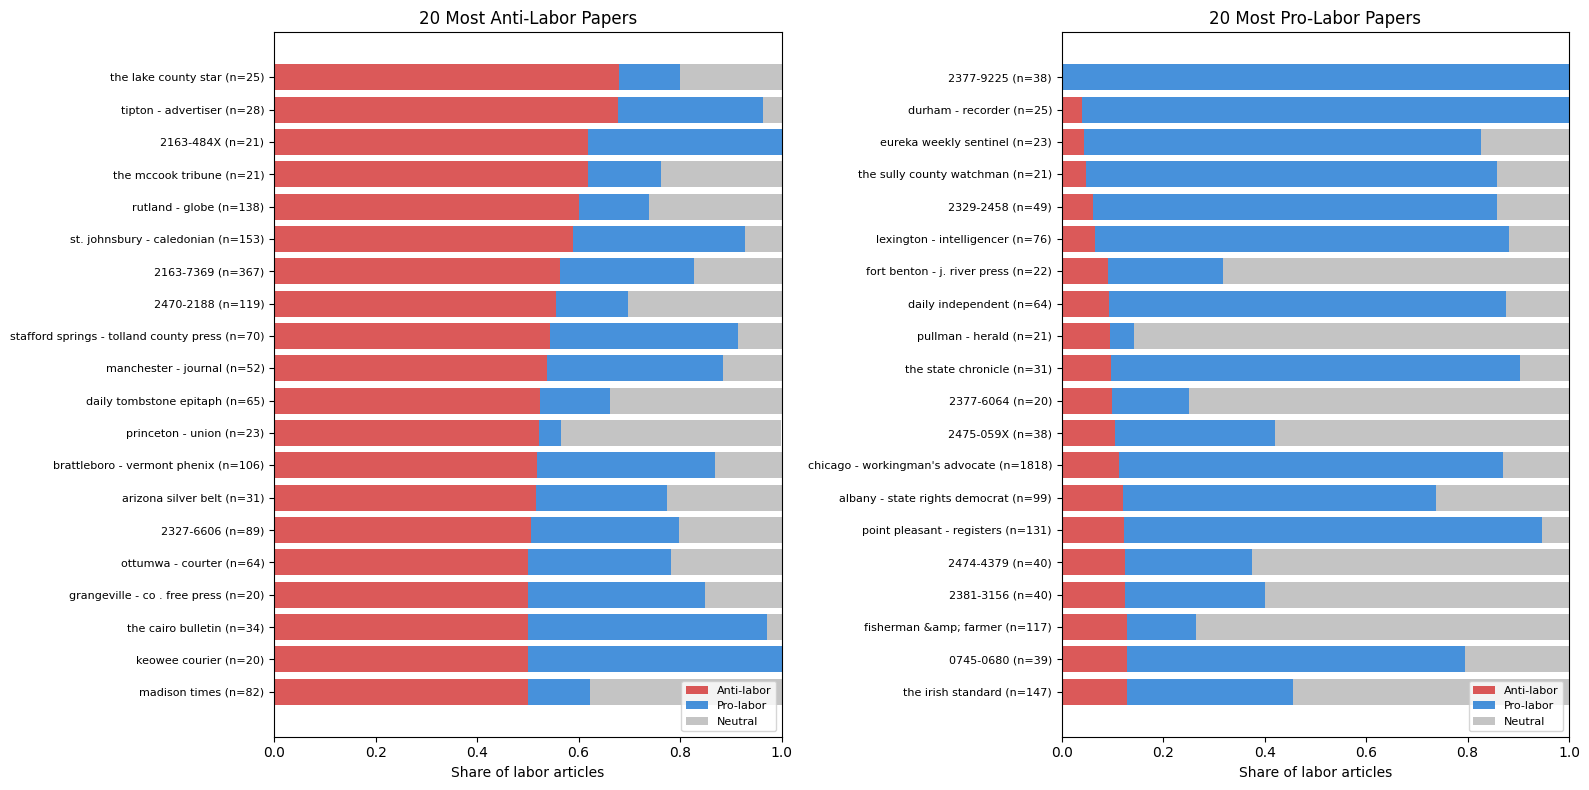

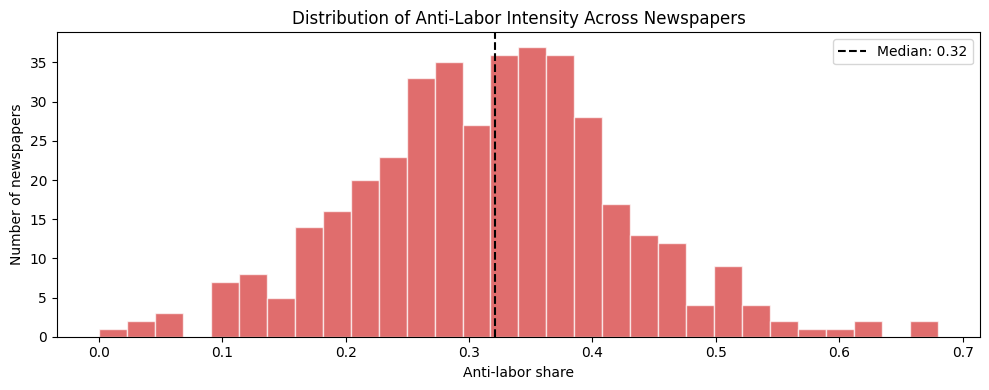

In [20]:
import matplotlib.pyplot as plt

# 8a. Labor sentiment distribution by newspaper
# Use all sentiment data (not just the regression sample)
conn = sqlite3.connect(DB_PATH)
all_sent = pd.read_sql("""
    SELECT issn, year, labor_sentiment
    FROM article_sentiment
    WHERE issn != '' AND labor_sentiment IS NOT NULL
""", conn)
conn.close()

# Aggregate to newspaper level
paper_sent = (
    all_sent.groupby(['issn', 'labor_sentiment']).size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ['anti_labor', 'pro_labor', 'neutral']:
    if col not in paper_sent.columns:
        paper_sent[col] = 0

paper_sent['total'] = paper_sent['anti_labor'] + paper_sent['pro_labor'] + paper_sent['neutral']
paper_sent['anti_labor_share'] = paper_sent['anti_labor'] / paper_sent['total']
paper_sent['pro_labor_share'] = paper_sent['pro_labor'] / paper_sent['total']

# Only papers with >= 20 labor articles for meaningful distributions
paper_sent_sig = paper_sent[paper_sent['total'] >= 20].copy()
paper_sent_sig = paper_sent_sig.sort_values('anti_labor_share', ascending=False)

# Add newspaper names from master.csv (covers all papers, not just coded ones)
paper_names = master[['issn', 'newspaper_name', 'town']].dropna(subset=['issn']).drop_duplicates('issn')
paper_sent_sig = paper_sent_sig.merge(paper_names, on='issn', how='left')
paper_sent_sig['label'] = paper_sent_sig.apply(
    lambda r: f"{str(r['town']).strip().lower()} - {str(r['newspaper_name']).strip().lower()}"
    if pd.notna(r['town']) and pd.notna(r['newspaper_name'])
    else str(r['newspaper_name']).strip().lower() if pd.notna(r['newspaper_name'])
    else r['issn'],
    axis=1
)

print(f"Newspapers with >= 20 labor articles: {len(paper_sent_sig)}")

# Plot top/bottom 20
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Most anti-labor
top = paper_sent_sig.head(20)
axes[0].barh(range(len(top)), top['anti_labor_share'], color='#d32f2f', alpha=0.8, label='Anti-labor')
axes[0].barh(range(len(top)), top['pro_labor_share'], left=top['anti_labor_share'], color='#1976d2', alpha=0.8, label='Pro-labor')
axes[0].barh(range(len(top)), 1 - top['anti_labor_share'] - top['pro_labor_share'],
             left=top['anti_labor_share'] + top['pro_labor_share'], color='#9e9e9e', alpha=0.6, label='Neutral')
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels([f"{r['label'][:40]} (n={r['total']})" for _, r in top.iterrows()], fontsize=8)
axes[0].set_title('20 Most Anti-Labor Papers')
axes[0].set_xlabel('Share of labor articles')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].invert_yaxis()

# Most pro-labor
bottom = paper_sent_sig.tail(20).iloc[::-1]
axes[1].barh(range(len(bottom)), bottom['anti_labor_share'], color='#d32f2f', alpha=0.8, label='Anti-labor')
axes[1].barh(range(len(bottom)), bottom['pro_labor_share'], left=bottom['anti_labor_share'], color='#1976d2', alpha=0.8, label='Pro-labor')
axes[1].barh(range(len(bottom)), 1 - bottom['anti_labor_share'] - bottom['pro_labor_share'],
             left=bottom['anti_labor_share'] + bottom['pro_labor_share'], color='#9e9e9e', alpha=0.6, label='Neutral')
axes[1].set_yticks(range(len(bottom)))
axes[1].set_yticklabels([f"{r['label'][:40]} (n={r['total']})" for _, r in bottom.iterrows()], fontsize=8)
axes[1].set_title('20 Most Pro-Labor Papers')
axes[1].set_xlabel('Share of labor articles')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Histogram of anti-labor intensity across all papers
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(paper_sent_sig['anti_labor_share'], bins=30, color='#d32f2f', alpha=0.7, edgecolor='white')
ax.axvline(paper_sent_sig['anti_labor_share'].median(), color='black', linestyle='--', label=f"Median: {paper_sent_sig['anti_labor_share'].median():.2f}")
ax.set_xlabel('Anti-labor share')
ax.set_ylabel('Number of newspapers')
ax.set_title('Distribution of Anti-Labor Intensity Across Newspapers')
ax.legend()
plt.tight_layout()
plt.show()

Persons with >= 20 labor articles during tenure: 208
  Of which railroad_interest=1: 18
  Of which railroad_interest=0: 23
  Uncoded (not in analysis):    167


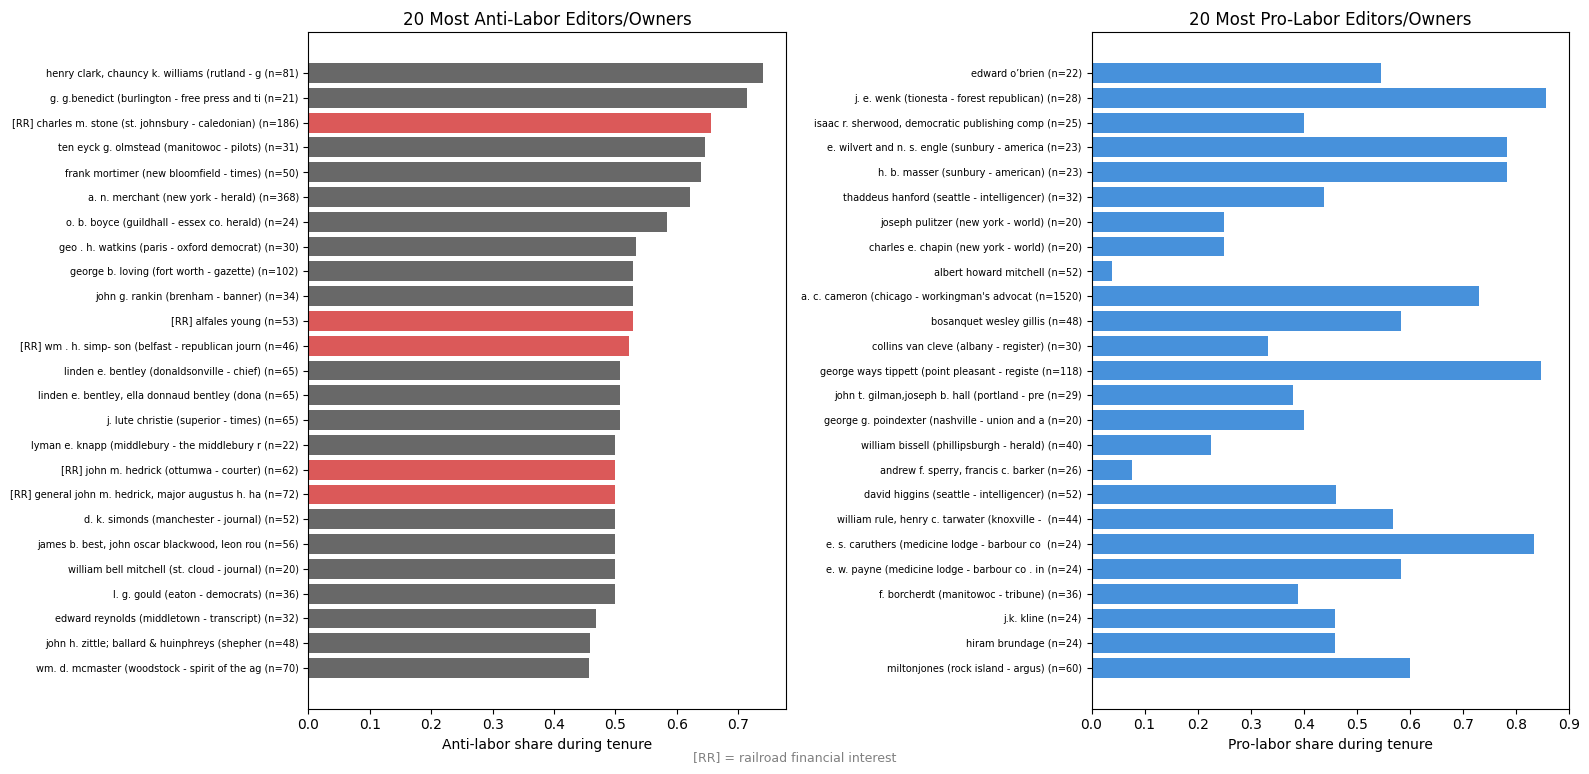

In [21]:
# 8b. Labor sentiment by editor/owner tenure
# For each person, compute sentiment during their active years at each paper

oe_persons_full = oe.dropna(subset=['person_id', 'issn']).copy()
oe_persons_full['person_id'] = oe_persons_full['person_id'].astype(int)

# Expand person-paper-year
tenure_rows = []
for _, row in oe_persons_full.iterrows():
    for yr in parse_years(row['years']):
        tenure_rows.append({
            'issn': row['issn'], 'year': yr,
            'person_id': row['person_id'],
            'name': row['name'],
            'role': row.get('role', ''),
        })

tenure = pd.DataFrame(tenure_rows)

# Merge with article-level sentiment
tenure_sent = tenure.merge(all_sent, on=['issn', 'year'], how='inner')

# Aggregate by person: sentiment distribution during their tenure
person_sent = (
    tenure_sent.groupby(['person_id', 'name', 'labor_sentiment']).size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['anti_labor', 'pro_labor', 'neutral']:
    if col not in person_sent.columns:
        person_sent[col] = 0

person_sent['total'] = person_sent['anti_labor'] + person_sent['pro_labor'] + person_sent['neutral']
person_sent['anti_labor_share'] = person_sent['anti_labor'] / person_sent['total']
person_sent['pro_labor_share'] = person_sent['pro_labor'] / person_sent['total']

# Only persons with >= 20 articles during their tenure
person_sent_sig = person_sent[person_sent['total'] >= 20].copy()
person_sent_sig = person_sent_sig.sort_values('anti_labor_share', ascending=False)

# Add railroad interest coding
person_sent_sig = person_sent_sig.merge(
    person_rr[['person_id', 'railroad_interest']], on='person_id', how='left'
)

# Add newspaper name + city from master.csv via owners_and_editors
person_papers = oe[['person_id', 'issn']].dropna(subset=['person_id']).drop_duplicates()
person_papers['person_id'] = person_papers['person_id'].astype(int)
person_papers = person_papers.merge(paper_names, on='issn', how='left')
# For persons at multiple papers, pick the first
person_paper_label = (
    person_papers.dropna(subset=['newspaper_name'])
    .groupby('person_id')
    .first()
    .reset_index()
)
person_sent_sig = person_sent_sig.merge(
    person_paper_label[['person_id', 'newspaper_name', 'town']], on='person_id', how='left'
)
person_sent_sig['label'] = person_sent_sig.apply(
    lambda r: f"{r['name'].strip().lower()} ({str(r['town']).strip().lower()} - {str(r['newspaper_name']).strip().lower()})"
    if pd.notna(r.get('town')) and pd.notna(r.get('newspaper_name'))
    else f"{r['name'].strip().lower()}" if pd.notna(r['name'])
    else str(r['person_id']),
    axis=1
)

print(f"Persons with >= 20 labor articles during tenure: {len(person_sent_sig)}")
print(f"  Of which railroad_interest=1: {(person_sent_sig['railroad_interest']==1).sum()}")
print(f"  Of which railroad_interest=0: {(person_sent_sig['railroad_interest']==0).sum()}")
print(f"  Uncoded (not in analysis):    {person_sent_sig['railroad_interest'].isna().sum()}")

# Plot top/bottom 20 persons
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_p = person_sent_sig.head(25)
colors_top = ['#d32f2f' if r.get('railroad_interest') == 1 else '#424242' for _, r in top_p.iterrows()]
axes[0].barh(range(len(top_p)), top_p['anti_labor_share'], color=colors_top, alpha=0.8)
axes[0].set_yticks(range(len(top_p)))
axes[0].set_yticklabels([f"{'[RR] ' if r.get('railroad_interest')==1 else ''}{r['label'][:45]} (n={r['total']})"
                         for _, r in top_p.iterrows()], fontsize=7)
axes[0].set_title('20 Most Anti-Labor Editors/Owners')
axes[0].set_xlabel('Anti-labor share during tenure')
axes[0].invert_yaxis()

bot_p = person_sent_sig.tail(25).iloc[::-1]
colors_bot = ['#d32f2f' if r.get('railroad_interest') == 1 else '#1976d2' for _, r in bot_p.iterrows()]
axes[1].barh(range(len(bot_p)), bot_p['pro_labor_share'], color=colors_bot, alpha=0.8)
axes[1].set_yticks(range(len(bot_p)))
axes[1].set_yticklabels([f"{'[RR] ' if r.get('railroad_interest')==1 else ''}{r['label'][:45]} (n={r['total']})"
                         for _, r in bot_p.iterrows()], fontsize=7)
axes[1].set_title('20 Most Pro-Labor Editors/Owners')
axes[1].set_xlabel('Pro-labor share during tenure')
axes[1].invert_yaxis()

plt.suptitle('[RR] = railroad financial interest', fontsize=9, y=0.02, color='gray')
plt.tight_layout()
plt.show()

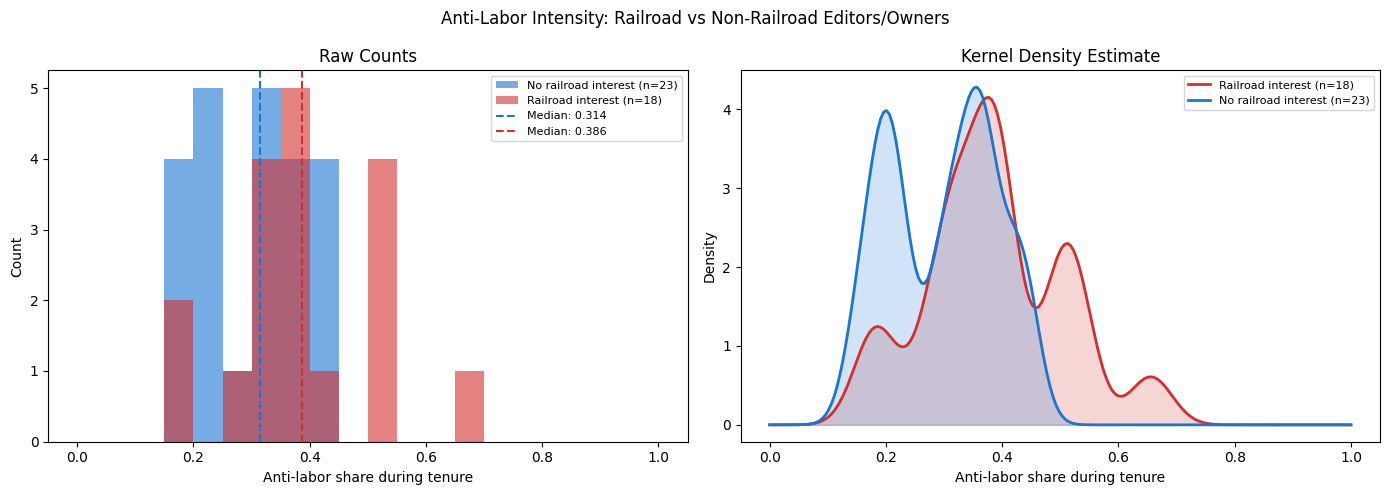

Railroad:     median=0.386, mean=0.386 (n=18)
Non-railroad: median=0.314, mean=0.299 (n=23)
KS test:           D=0.437, p=0.0287
Mann-Whitney U:    U=292, p=0.0264


In [22]:
# 8b continued: Compare distributions by railroad interest
coded = person_sent_sig.dropna(subset=['railroad_interest'])

rr = coded[coded['railroad_interest'] == 1]['anti_labor_share']
no_rr = coded[coded['railroad_interest'] == 0]['anti_labor_share']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw count histograms
bins = np.linspace(0, 1, 21)
axes[0].hist(no_rr, bins=bins, alpha=0.6, color='#1976d2', label=f'No railroad interest (n={len(no_rr)})')
axes[0].hist(rr, bins=bins, alpha=0.6, color='#d32f2f', label=f'Railroad interest (n={len(rr)})')
axes[0].axvline(no_rr.median(), color='#1976d2', linestyle='--', linewidth=1.5, label=f'Median: {no_rr.median():.3f}')
axes[0].axvline(rr.median(), color='#d32f2f', linestyle='--', linewidth=1.5, label=f'Median: {rr.median():.3f}')
axes[0].set_xlabel('Anti-labor share during tenure')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Counts')
axes[0].legend(fontsize=8)

# Right: KDE (smoothed density)
from scipy.stats import gaussian_kde
x_grid = np.linspace(0, 1, 200)
if len(rr) >= 2:
    kde_rr = gaussian_kde(rr, bw_method=0.3)
    axes[1].plot(x_grid, kde_rr(x_grid), color='#d32f2f', linewidth=2, label=f'Railroad interest (n={len(rr)})')
    axes[1].fill_between(x_grid, kde_rr(x_grid), alpha=0.2, color='#d32f2f')
if len(no_rr) >= 2:
    kde_norr = gaussian_kde(no_rr, bw_method=0.3)
    axes[1].plot(x_grid, kde_norr(x_grid), color='#1976d2', linewidth=2, label=f'No railroad interest (n={len(no_rr)})')
    axes[1].fill_between(x_grid, kde_norr(x_grid), alpha=0.2, color='#1976d2')
axes[1].set_xlabel('Anti-labor share during tenure')
axes[1].set_ylabel('Density')
axes[1].set_title('Kernel Density Estimate')
axes[1].legend(fontsize=8)

plt.suptitle('Anti-Labor Intensity: Railroad vs Non-Railroad Editors/Owners', fontsize=12)
plt.tight_layout()
plt.show()

# Statistical tests
from scipy.stats import ks_2samp, mannwhitneyu
ks_stat, ks_p = ks_2samp(rr, no_rr)
u_stat, u_p = mannwhitneyu(rr, no_rr, alternative='two-sided')
print(f"Railroad:     median={rr.median():.3f}, mean={rr.mean():.3f} (n={len(rr)})")
print(f"Non-railroad: median={no_rr.median():.3f}, mean={no_rr.mean():.3f} (n={len(no_rr)})")
print(f"KS test:           D={ks_stat:.3f}, p={ks_p:.4f}")
print(f"Mann-Whitney U:    U={u_stat:.0f}, p={u_p:.4f}")

## 9. Highest-Value Uncoded Owners/Editors

Which owners/editors have the most newspaper-years of article data but have not yet been coded for railroad ties?

In [23]:
# Load data
oe = pd.read_csv(OE_PATH)
coding = pd.read_csv(CODE_PATH)
conn = sqlite3.connect(DB_PATH)

# Get newspaper-years that have article data
article_ny = pd.read_sql("""
    SELECT issn, year, COUNT(*) as n_articles
    FROM article_sentiment
    GROUP BY issn, year
""", conn)
conn.close()

# Keep only person rows (non-null person_id)
oe_persons = oe.dropna(subset=['person_id']).copy()
oe_persons['person_id'] = oe_persons['person_id'].astype(int)

# Expand each owner's tenure into individual years
rows = []
for _, r in oe_persons.iterrows():
    for y in range(int(r['first_year']), int(r['last_year']) + 1):
        rows.append({'person_id': r['person_id'], 'name': r['name'],
                      'issn': r['issn'], 'year': y})
person_years = pd.DataFrame(rows)

# Join to article data â€” only count years where we actually have articles
person_articles = person_years.merge(article_ny, on=['issn', 'year'], how='inner')

# Aggregate per person
person_summary = (
    person_articles
    .groupby(['person_id', 'name'])
    .agg(newspaper_years=('year', 'nunique'),
         total_articles=('n_articles', 'sum'),
         newspapers=('issn', 'nunique'))
    .reset_index()
    .sort_values('total_articles', ascending=False)
)

# "Coded" = has at least one non-NaN value in the railroad columns
RAILROAD_COLS = [
    'railroad_stockholder', 'railroad_board_member', 'railroad_company_owner',
    'railroad_donation', 'railroad_professional_services', 'family_connection_railroad'
]
coded_ids = set(
    coding.loc[coding[RAILROAD_COLS].notna().any(axis=1), 'person_id']
    .dropna().astype(int)
)
person_summary['coded'] = person_summary['person_id'].isin(coded_ids)

# Show top 10 by total articles, highlighting coded status
top10 = person_summary.head(35)[['name', 'person_id', 'newspapers', 'newspaper_years', 'total_articles', 'coded']]
print(f"Top 10 owners/editors by article volume (coded: {top10['coded'].sum()}/10)\n")
top10

Top 10 owners/editors by article volume (coded: 28/10)



,name,person_id,newspapers,newspaper_years,total_articles,coded
2,Crosby Noyes,5,1,22,5764,True
12,Lewis Baker,24,4,22,5006,True
11,Harlan P. Hall,22,2,13,4770,True
17,Berry R. Sulgrove,37,1,8,3904,True
16,John C. New,36,1,8,3904,True
0,Whitelaw Reid,3,1,14,2704,True
30,J. H. Estill,71,2,10,2397,True
321,A. C. Cameron,738,1,7,2212,False
24,John F. Morse,52,1,11,1622,True
5,James Gordon Ben- nett,13,1,9,1501,True


In [24]:
# Coded persons: those with at least one non-NaN railroad column
coded_persons = coding[coding[RAILROAD_COLS].notna().any(axis=1)].copy()
coded_persons['railroad_interest'] = (coded_persons[RAILROAD_COLS].fillna(0) > 0).any(axis=1).astype(int)

# Expand coded persons' tenures into person-paper-year rows
oe_coded = oe.dropna(subset=['person_id', 'issn']).copy()
oe_coded['person_id'] = oe_coded['person_id'].astype(int)
oe_coded = oe_coded[oe_coded['person_id'].isin(coded_persons['person_id'])]

coded_tenure = []
for _, row in oe_coded.iterrows():
    for yr in range(int(row['first_year']), int(row['last_year']) + 1):
        coded_tenure.append({'person_id': row['person_id'], 'issn': row['issn'], 'year': yr})
coded_tenure = pd.DataFrame(coded_tenure)

# Load sentiment counts
conn = sqlite3.connect(DB_PATH)
sent = pd.read_sql("""
    SELECT issn, year, labor_sentiment
    FROM article_sentiment
    WHERE issn != '' AND labor_sentiment IS NOT NULL
""", conn)
conn.close()

sent_counts = (
    sent.groupby(['issn', 'year', 'labor_sentiment'])
    .size().unstack(fill_value=0).reset_index()
)
for col in ['anti_labor', 'pro_labor', 'neutral']:
    if col not in sent_counts.columns:
        sent_counts[col] = 0
sent_counts['total_labor'] = sent_counts['anti_labor'] + sent_counts['pro_labor'] + sent_counts['neutral']
sent_counts['anti_labor_intensity'] = sent_counts['anti_labor'] / sent_counts['total_labor']

# Join person-years to sentiment, aggregate per person
person_sent = coded_tenure.merge(sent_counts, on=['issn', 'year'], how='inner')
person_agg = (
    person_sent
    .groupby('person_id')
    .agg(anti_labor=('anti_labor', 'sum'), total_labor=('total_labor', 'sum'))
    .reset_index()
)
person_agg['anti_labor_intensity'] = person_agg['anti_labor'] / person_agg['total_labor']

# Merge with coded person info
result = coded_persons[['person_id', 'name', 'railroad_interest']].merge(
    person_agg[['person_id', 'anti_labor_intensity', 'total_labor']], on='person_id', how='left'
)
result['treated'] = result['railroad_interest'].map({1: 'Yes', 0: 'No'})
result = result.sort_values('anti_labor_intensity', ascending=False)

print(f"Coded persons: {len(result)} ({result['treated'].value_counts().to_dict()})\n")
result[['name', 'treated', 'anti_labor_intensity', 'total_labor']].reset_index(drop=True)

Coded persons: 47 ({'No': 26, 'Yes': 21})



,name,treated,anti_labor_intensity,total_labor
0,Charles M. Stone,Yes,0.588235,306.0
1,Alfales Young,Yes,0.528302,53.0
2,Wm. H. Simpson,Yes,0.517241,58.0
3,General John M. Hedrick | Major Augustus H. Ha...,Yes,0.513514,74.0
4,C. S. Douglas,No,0.500000,4.0
5,John M. Hedrick,Yes,0.500000,64.0
6,C. W. Willard,Yes,0.500000,2.0
7,James Gordon Bennett,Yes,0.423718,1501.0
8,Buckley B. Paddock | Walter Malone,Yes,0.407229,1245.0
9,Whitelaw Reid,Yes,0.406065,2704.0


---

## 10. Test 1: Keyword-Based Anti-Labor Score

A model-free outcome: for each labor article (already classified by the sentiment pipeline) count whether it contains any of a set of anti-labor sentiment keywords (*mob, agitator, rioter, anarchist, communist*, etc.). The newspaper-year outcome is the **share of labor articles containing at least one anti-labor keyword**.

This test is independent of the Gemini classification model and validates whether the framing difference between railroad-tied and non-railroad papers is detectable in raw word choice.

In [25]:
import hashlib

ANTI_LABOR_KEYWORDS = [
    'mob', 'agitator', 'agitators', 'rioter', 'rioters',
    'anarchist', 'anarchists', 'communist', 'communists', 'communism',
    'lawless', 'incendiary', 'rabble', 'disorderly',
    'dangerous classes', 'tramp', 'vagabond', 'vagabonds',
    'instigator', 'instigators', 'troublemaker',
    'incited', 'inflamed', 'radical element',
]

def make_article_id(lccn: str, issn: str, year: int, text: str) -> str:
    raw = f"{lccn}|{issn}|{year}|{text[:500]}"
    return hashlib.sha256(raw.encode('utf-8', errors='replace')).hexdigest()[:16]

def has_antilabor_keyword(text: str) -> int:
    t = text.lower()
    return int(any(kw in t for kw in ANTI_LABOR_KEYWORDS))

# Pull all labor article IDs for the analysis sample (issn, year) pairs
analysis_pairs = set(zip(df['issn'], df['year']))
conn = sqlite3.connect(DB_PATH)
labor_meta = pd.read_sql(
    "SELECT article_id, lccn, issn, year FROM article_sentiment "
    "WHERE labor_sentiment IS NOT NULL AND issn != ''",
    conn
)
conn.close()

# Filter to analysis sample only
labor_meta = labor_meta[
    labor_meta.apply(lambda r: (r['issn'], r['year']) in analysis_pairs, axis=1)
].copy()

print(f"Labor articles in analysis sample : {len(labor_meta)}")
print(f"Distinct (lccn, year) groups to query: {labor_meta.groupby(['lccn','year']).ngroups}")


Labor articles in analysis sample : 12579
Distinct (lccn, year) groups to query: 267


In [26]:
# Fetch article texts and compute keyword scores.
# Uses the (lccn, year) index on the articles table for speed (~0.1s per group).
needed_ids = set(labor_meta['article_id'])
groups = list(labor_meta.groupby(['lccn', 'issn', 'year']))

conn = sqlite3.connect(DB_PATH)
scores = []
for i, ((lccn, issn, year), _) in enumerate(groups):
    arts = pd.read_sql(
        'SELECT text FROM articles WHERE lccn=? AND year=?',
        conn, params=[lccn, int(year)]
    )
    for text in arts['text']:
        aid = make_article_id(lccn, issn, int(year), text)
        if aid in needed_ids:
            scores.append({'article_id': aid, 'keyword_hit': has_antilabor_keyword(text)})
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(groups)} groups processed, {len(scores)} articles matched so far")
conn.close()

scores_df = pd.DataFrame(scores)
print(f"\nMatched {len(scores_df)} / {len(labor_meta)} labor articles")


  50/267 groups processed, 3695 articles matched so far
  100/267 groups processed, 7593 articles matched so far
  150/267 groups processed, 8688 articles matched so far
  200/267 groups processed, 9712 articles matched so far
  250/267 groups processed, 11441 articles matched so far

Matched 12587 / 12579 labor articles


In [27]:
# Aggregate to newspaper-year: share of labor articles with any anti-labor keyword
kw_agg = (
    labor_meta.merge(scores_df, on='article_id', how='inner')
    .groupby(['issn', 'year'])
    .agg(kw_hits=('keyword_hit', 'sum'), total_scored=('keyword_hit', 'count'))
    .reset_index()
)
kw_agg['keyword_score'] = kw_agg['kw_hits'] / kw_agg['total_scored']

df_kw     = df.merge(kw_agg, on=['issn', 'year'], how='inner')
df_kw_pol = df_kw.dropna(subset=['republican']).copy()

print(f"Keyword regression sample: {len(df_kw)} obs")
print()
print(df_kw.groupby('railroad_interest')[['keyword_score']].describe().T)


Keyword regression sample: 265 obs

railroad_interest             0           1
keyword_score count  151.000000  114.000000
              mean     0.143206    0.129910
              std      0.158738    0.127156
              min      0.000000    0.000000
              25%      0.000000    0.031234
              50%      0.095238    0.101020
              75%      0.188312    0.180114
              max      0.750000    0.714286


In [28]:
# Test 1 regressions: keyword score as outcome
k1 = smf.ols('keyword_score ~ railroad_interest', data=df_kw).fit(cov_type='HC3')
k2 = smf.ols('keyword_score ~ railroad_interest + C(year)', data=df_kw).fit(cov_type='HC3')
k4 = smf.ols('keyword_score ~ railroad_interest + C(year) + republican',
             data=df_kw_pol).fit(cov_type='HC3')

print('=== Test 1: Keyword-Based Anti-Labor Score ===')
print(summary_col(
    [k1, k2, k4],
    model_names=['(1) Bivariate', '(2) Year FE', '(3) Year FE + Party'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'R²': lambda m: round(m.rsquared, 3)},
    regressor_order=['railroad_interest', 'republican', 'Intercept']
))


=== Test 1: Keyword-Based Anti-Labor Score ===

                  (1) Bivariate (2) Year FE (3) Year FE + Party
---------------------------------------------------------------
railroad_interest -0.0133       -0.0230     -0.0411*           
                  (0.0176)      (0.0147)    (0.0239)           
republican                                  0.0057             
                                            (0.0287)           
Intercept         0.1432***     0.1067**    0.2172             
                  (0.0130)      (0.0450)    (0.1540)           
C(year)[T.1871]                 0.0215      -0.1011            
                                (0.0656)    (0.1967)           
C(year)[T.1872]                 -0.0052     -0.0935            
                                (0.0597)    (0.1748)           
C(year)[T.1873]                 -0.0101     -0.1158            
                                (0.0504)    (0.1621)           
C(year)[T.1876]                 0.0407      0.0388      

---

## 11. Test 2: Raw Sentiment Score as Outcome

Instead of a binary anti- / pro-labor classification, use the model's **confidence score** as a continuous directional signal:

- `+confidence` if the article is classified **anti_labor**
- `-confidence` if the article is classified **pro_labor**
- `0` if **neutral**

Aggregated to the newspaper-year as the **mean signed score** across all labor articles. Positive values indicate net anti-labor framing; negative values indicate net pro-labor framing. This exploits variation in framing intensity that the binary outcome discards.

In [29]:
# Compute signed sentiment score from labor_confidence
conn = sqlite3.connect(DB_PATH)
sent_conf = pd.read_sql(
    """SELECT issn, year, labor_sentiment, labor_confidence
       FROM article_sentiment
       WHERE labor_sentiment IS NOT NULL AND issn != ''""",
    conn
)
conn.close()

def signed_score(row):
    if row['labor_sentiment'] == 'anti_labor':
        return row['labor_confidence']
    elif row['labor_sentiment'] == 'pro_labor':
        return -row['labor_confidence']
    return 0.0

sent_conf['signed_score'] = sent_conf.apply(signed_score, axis=1)

# Aggregate to newspaper-year: mean signed score
signed_agg = (
    sent_conf.groupby(['issn', 'year'])
    .agg(mean_sentiment=('signed_score', 'mean'),
         n_articles=('signed_score', 'count'))
    .reset_index()
)

df_raw     = df.merge(signed_agg, on=['issn', 'year'], how='inner')
df_raw_pol = df_raw.dropna(subset=['republican']).copy()

print(f"Raw sentiment regression sample: {len(df_raw)} obs")
print(f"Signed score range: [{sent_conf['signed_score'].min():.3f}, {sent_conf['signed_score'].max():.3f}]")
print()
print('Mean signed score by treatment group:')
print(df_raw.groupby('railroad_interest')['mean_sentiment'].describe().T)


Raw sentiment regression sample: 265 obs
Signed score range: [-0.929, 0.955]

Mean signed score by treatment group:
railroad_interest           0           1
count              151.000000  114.000000
mean                -0.098977   -0.024972
std                  0.353209    0.314434
min                 -0.918000   -0.923500
25%                 -0.318292   -0.168007
50%                 -0.010455    0.005090
75%                  0.102033    0.172525
max                  0.918000    0.742167


In [30]:
# Test 2 regressions: mean signed sentiment as outcome
r1 = smf.ols('mean_sentiment ~ railroad_interest', data=df_raw).fit(cov_type='HC3')
r2 = smf.ols('mean_sentiment ~ railroad_interest + C(year)', data=df_raw).fit(cov_type='HC3')
r4 = smf.ols('mean_sentiment ~ railroad_interest + C(year) + republican',
             data=df_raw_pol).fit(cov_type='HC3')

print('=== Test 2: Raw Sentiment Score (Mean Signed Confidence) ===')
print(summary_col(
    [r1, r2, r4],
    model_names=['(1) Bivariate', '(2) Year FE', '(3) Year FE + Party'],
    stars=True,
    info_dict={'N': lambda m: m.nobs, 'R²': lambda m: round(m.rsquared, 3)},
    regressor_order=['railroad_interest', 'republican', 'Intercept']
))


=== Test 2: Raw Sentiment Score (Mean Signed Confidence) ===

                  (1) Bivariate (2) Year FE (3) Year FE + Party
---------------------------------------------------------------
railroad_interest 0.0740*       0.0672*     0.0586             
                  (0.0413)      (0.0406)    (0.0564)           
republican                                  0.1395**           
                                            (0.0560)           
Intercept         -0.0990***    -0.2311**   -0.3014            
                  (0.0288)      (0.1179)    (0.3679)           
C(year)[T.1871]                 -0.0255     -0.1803            
                                (0.1517)    (0.4067)           
C(year)[T.1872]                 0.1604      0.1407             
                                (0.1500)    (0.4031)           
C(year)[T.1873]                 0.1412      0.1280             
                                (0.1334)    (0.3783)           
C(year)[T.1876]                 0.1143    

---

## 12. Test 3: Refined Keyword Net Score

Expands the keyword approach into separate anti-labor and pro-labor lists focused on **framing language**
(rather than inflammatory nouns), then computes a per-article net score aggregated to newspaper-year level.

* **Anti-labor keywords:** order, property, trespass, lawless, dangerous, incendiary, rioters, agitators,
  troops, militia, dispersed, arrested, suppressed, quelled, violence, destruction, disturbance
* **Pro-labor keywords:** wages, grievance, organize, union, rights, fair, peaceable, assembly, demands,
  concession, settlement, workers, laborers, employees, justice

Net score = (anti\_hits − pro\_hits) / (anti\_hits + pro\_hits), 0 when neither list fires.

In [ ]:
import re

ANTI_LABOR_KW = re.compile(
    r"\b(order|property|trespass|lawless|dangerous|incendiary|rioters?|agitators?"
    r"|troops?|militia|disperse[sd]?|arrest(?:ed|s)?|suppress(?:ed|ion)?|quell(?:ed)?"
    r"|violence|destruction|disturbance)\b",
    re.IGNORECASE
)
PRO_LABOR_KW = re.compile(
    r"\b(wages?|grievance|organiz(?:e[sd]?|ation)|union|rights?|fair|peaceable|assembly"
    r"|demands?|concession|settlement|workers?|labou?rers?|employees?|justice)\b",
    re.IGNORECASE
)

def net_kw_score(text):
    if not isinstance(text, str):
        return None
    anti = len(ANTI_LABOR_KW.findall(text))
    pro  = len(PRO_LABOR_KW.findall(text))
    denom = anti + pro
    if denom == 0:
        return 0.0
    return (anti - pro) / denom

# Only query (lccn, year) groups in the analysis sample, using the DB index
analysis_pairs = set(zip(df['issn'], df['year']))
conn = sqlite3.connect(DB_PATH)
lccn_issn = pd.read_sql("SELECT DISTINCT lccn, issn FROM articles", conn)

# Build lookup of issn -> lccn(s)
issn_to_lccns = lccn_issn.groupby('issn')['lccn'].apply(set).to_dict()

# Gather (lccn, year) groups we actually need
query_groups = []
for issn, year in analysis_pairs:
    for lccn in issn_to_lccns.get(issn, []):
        query_groups.append((lccn, issn, int(year)))

scores = []
for i, (lccn, issn, year) in enumerate(query_groups):
    arts = pd.read_sql(
        'SELECT text FROM articles WHERE lccn=? AND year=?',
        conn, params=[lccn, year]
    )
    for text in arts['text']:
        score = net_kw_score(text)
        if score is not None:
            scores.append({'lccn': lccn, 'issn': issn, 'year': year, 'net_kw': score})
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(query_groups)} groups processed")

conn.close()
scores_df = pd.DataFrame(scores)

net_kw_agg = (
    scores_df.groupby(["issn", "year"])["net_kw"]
    .mean().reset_index()
    .rename(columns={"net_kw": "net_kw_score"})
)
df_netkw = df.merge(net_kw_agg, on=["issn","year"], how="inner")
print(f"Net keyword sample: {len(df_netkw)} newspaper-years")
print(df_netkw.groupby("railroad_interest")["net_kw_score"].describe().round(3))

In [ ]:
from statsmodels.iolib.summary2 import summary_col

nk1 = smf.ols("net_kw_score ~ railroad_interest", data=df_netkw).fit(cov_type="HC3")
nk2 = smf.ols("net_kw_score ~ railroad_interest + C(year_str)", data=df_netkw).fit(cov_type="HC3")
nk3 = smf.ols("net_kw_score ~ railroad_interest + C(year_str) + C(state)", data=df_netkw).fit(cov_type="HC3")

print(summary_col(
    [nk1, nk2, nk3],
    model_names=["Bivariate","Year FE","Year+State FE"],
    stars=True,
    info_dict={"N": lambda m: f"{int(m.nobs)}", "R2": lambda m: f"{m.rsquared:.3f}"}
))

---

## 13. Test 4: Outcome Framing Vocabulary

Focuses on how papers describe *the resolution* of labor disputes — the most unambiguous framing signal.

* **Anti-labor outcome words:** dispersed, arrested, suppressed, defeated, quelled, crushed, routed, driven off, expelled
* **Pro-labor outcome words:** settled, conceded, won, recognized, granted, agreed, succeeded, secured, achieved

Score = (anti\_outcome\_hits − pro\_outcome\_hits) / (anti + pro), excluding articles with no outcome vocabulary.

In [ ]:
ANTI_OUTCOME = re.compile(
    r"\b(disperse[sd]?|arrest(?:ed|s)?|suppress(?:ed)?|defeat(?:ed)?|quell(?:ed)?"
    r"|crush(?:ed)?|rout(?:ed)?|driven\s+off|expell?(?:ed)?)\b",
    re.IGNORECASE
)
PRO_OUTCOME = re.compile(
    r"\b(settle[sd]?|settlement|conced(?:ed)?|won|recogniz(?:ed)?|grant(?:ed)?"
    r"|agre(?:ed)?|succeed(?:ed)?|secur(?:ed)?|achiev(?:ed)?)\b",
    re.IGNORECASE
)

def outcome_score(text):
    if not isinstance(text, str):
        return None
    anti = len(ANTI_OUTCOME.findall(text))
    pro  = len(PRO_OUTCOME.findall(text))
    denom = anti + pro
    if denom == 0:
        return 0.0
    return (anti - pro) / denom

# Reuse query_groups and conn pattern from cell above
conn = sqlite3.connect(DB_PATH)
outcome_scores = []
for i, (lccn, issn, year) in enumerate(query_groups):
    arts = pd.read_sql(
        'SELECT text FROM articles WHERE lccn=? AND year=?',
        conn, params=[lccn, year]
    )
    for text in arts['text']:
        score = outcome_score(text)
        if score is not None:
            outcome_scores.append({'lccn': lccn, 'issn': issn, 'year': year, 'outcome_framing': score})
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(query_groups)} groups processed")

conn.close()
outcome_df = pd.DataFrame(outcome_scores)

outcome_agg = (
    outcome_df.groupby(["issn","year"])["outcome_framing"]
    .mean().reset_index()
    .rename(columns={"outcome_framing": "outcome_score"})
)
df_outcome = df.merge(outcome_agg, on=["issn","year"], how="inner")
print(f"Outcome framing sample: {len(df_outcome)} newspaper-years")
print(df_outcome.groupby("railroad_interest")["outcome_score"].describe().round(3))

In [ ]:
oc1 = smf.ols("outcome_score ~ railroad_interest", data=df_outcome).fit(cov_type="HC3")
oc2 = smf.ols("outcome_score ~ railroad_interest + C(year_str)", data=df_outcome).fit(cov_type="HC3")
oc3 = smf.ols("outcome_score ~ railroad_interest + C(year_str) + C(state)", data=df_outcome).fit(cov_type="HC3")

print(summary_col(
    [oc1, oc2, oc3],
    model_names=["Bivariate","Year FE","Year+State FE"],
    stars=True,
    info_dict={"N": lambda m: f"{int(m.nobs)}", "R2": lambda m: f"{m.rsquared:.3f}"}
))

---

## 14. Test 5: Source Attribution (Management vs. Worker Quotes)

Proxies for *whose voice* articles amplify by counting attribution phrases near reported speech.

* **Management-attributed:** "the company/superintendent/employer/manager/president said/stated/declared"
* **Worker-attributed:** "the strikers/workers/union/laborers/employees/the men/committee said/stated/claimed/demanded"

Score = (mgmt\_hits − worker\_hits) / (mgmt\_hits + worker\_hits), only for articles with at least one hit.
Positive score = management-voiced; negative = worker-voiced.

In [ ]:
MGMT_ATTR = re.compile(
    r"\b(?:the\s+)?(?:company|superintendent|employer|manager|president|proprietor|firm|corporation|management)"
    r"\s+(?:said|stated?|declared?|announced?|replied?|insisted?|maintained?)",
    re.IGNORECASE
)
WORKER_ATTR = re.compile(
    r"\b(?:the\s+)?(?:strikers?|workers?|union|labou?rers?|employees?|the\s+men|committee)"
    r"\s+(?:said|stated?|claimed?|demanded?|replied?|asserted?|maintained?)",
    re.IGNORECASE
)

def attribution_score(text):
    if not isinstance(text, str):
        return None
    mgmt   = len(MGMT_ATTR.findall(text))
    worker = len(WORKER_ATTR.findall(text))
    denom  = mgmt + worker
    if denom == 0:
        return None  # no attributed speech found — exclude
    return (mgmt - worker) / denom

labor_articles["attr_score"] = labor_articles["text"].apply(attribution_score)

attr_agg = (
    labor_articles.dropna(subset=["attr_score"])
    .groupby(["lccn","year"])["attr_score"]
    .mean().reset_index()
)
attr_agg = attr_agg.merge(lccn_issn, on="lccn", how="left")
df_attr = df.merge(attr_agg[["issn","year","attr_score"]], on=["issn","year"], how="inner")
print(f"Attribution sample: {len(df_attr)} newspaper-years (articles with attributed quotes only)")
print(df_attr.groupby("railroad_interest")["attr_score"].describe().round(3))

In [ ]:
at1 = smf.ols("attr_score ~ railroad_interest", data=df_attr).fit(cov_type="HC3")
at2 = smf.ols("attr_score ~ railroad_interest + C(year_str)", data=df_attr).fit(cov_type="HC3")
at3 = smf.ols("attr_score ~ railroad_interest + C(year_str) + C(state)", data=df_attr).fit(cov_type="HC3")

print(summary_col(
    [at1, at2, at3],
    model_names=["Bivariate","Year FE","Year+State FE"],
    stars=True,
    info_dict={"N": lambda m: f"{int(m.nobs)}", "R2": lambda m: f"{m.rsquared:.3f}"}
))

---

## 15. Test 6: TF-IDF Vocabulary Gap

Unsupervised check: fit TF-IDF on railroad-tied vs. non-railroad paper corpora and compare term weights.
Surfaces framing differences not anticipated by the researcher and can inform future keyword lists.

Includes unigrams and bigrams; standard English stopwords removed.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Map lccn -> railroad_interest via issn
rr_map = df[["issn","railroad_interest"]].drop_duplicates().set_index("issn")["railroad_interest"]
labor_articles["rr"] = (
    labor_articles["lccn"]
    .map(lccn_issn.set_index("lccn")["issn"])
    .map(rr_map)
)

rr_corpus   = " ".join(labor_articles[labor_articles["rr"] == 1]["text"].dropna().tolist())
ctrl_corpus = " ".join(labor_articles[labor_articles["rr"] == 0]["text"].dropna().tolist())

print(f"Railroad corpus:  {len(rr_corpus):>12,} chars")
print(f"Control corpus:   {len(ctrl_corpus):>12,} chars")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=1
)
mat   = tfidf.fit_transform([rr_corpus, ctrl_corpus])
terms = np.array(tfidf.get_feature_names_out())

scores_rr   = mat[0].toarray().flatten()
scores_ctrl = mat[1].toarray().flatten()
diff = scores_rr - scores_ctrl

top_rr_idx   = np.argsort(-diff)[:30]
top_ctrl_idx = np.argsort( diff)[:30]

print("\n=== Top 30 terms OVER-INDEXING in railroad-tied papers ===")
for t, s in zip(terms[top_rr_idx], diff[top_rr_idx]):
    print(f"  {t:<35} +{s:.4f}")

print("\n=== Top 30 terms OVER-INDEXING in non-railroad (control) papers ===")
for t, s in zip(terms[top_ctrl_idx], -diff[top_ctrl_idx]):
    print(f"  {t:<35} +{s:.4f}")